<div style="text-align: center;">

# Social Network Analysis (CS342) | Assignment 9

## **SimRank Algorithm: Citation Network Similarity Analysis**

---

**Student Name:** *Naishadh Rana*

**Roll No:** U23CS014

---

</div>

## Problem Statement

Given a toy citation network:

```plain
E → C, D
C → A
D → B
F → A
G → A
H → B, G
```

**Tasks:**
1. Build the citation network graph
2. Implement SimRank algorithm (Section 4.2)
3. Calculate pairwise similarity between all nodes
4. Analyze and visualize the results

**Required Libraries:** `networkx`, `matplotlib`, `pandas`, `numpy`

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from collections import defaultdict
from itertools import combinations

print("Imports successful")

Imports successful


## Graph Setup

Create the toy citation network as specified in the problem statement using directed edges.

In [2]:
# Create directed graph
G = nx.DiGraph()

# Add nodes
nodes = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']
G.add_nodes_from(nodes)

# Add edges (source -> target representing citations)
edges = [
    ('E', 'C'),
    ('E', 'D'),
    ('C', 'A'),
    ('D', 'B'),
    ('F', 'A'),
    ('G', 'A'),
    ('H', 'B'),
    ('H', 'G')
]
G.add_edges_from(edges)

print("Graph created")
print(f"Nodes: {sorted(G.nodes())}")
print(f"Edges: {G.edges()}")
print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")

Graph created
Nodes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']
Edges: [('C', 'A'), ('D', 'B'), ('E', 'C'), ('E', 'D'), ('F', 'A'), ('G', 'A'), ('H', 'B'), ('H', 'G')]
Number of nodes: 8
Number of edges: 8


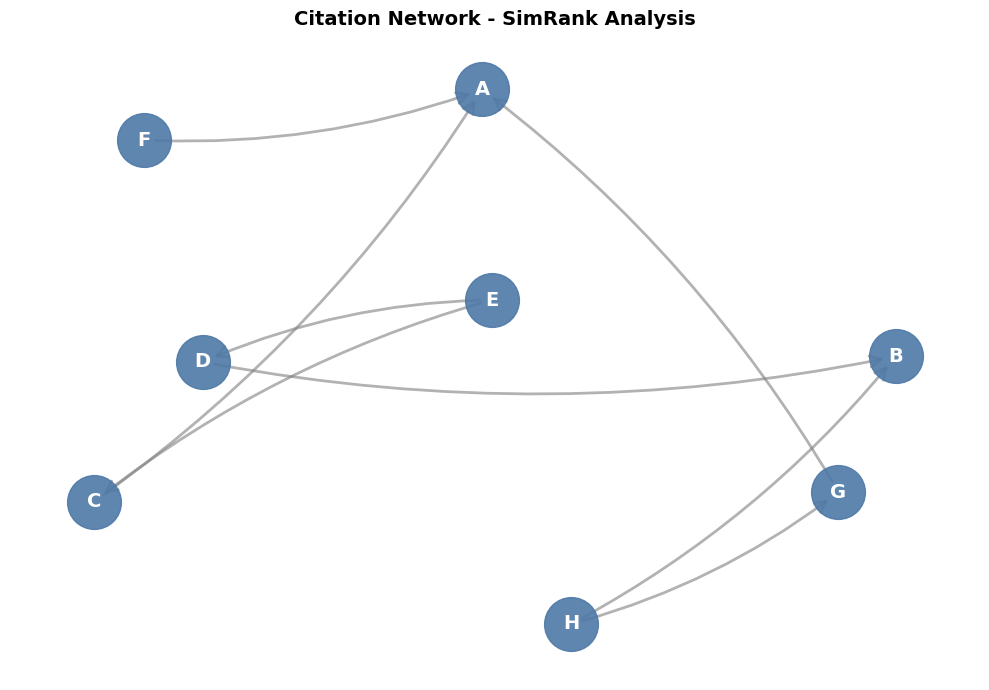

In [3]:
# Visualize the network
plt.figure(figsize=(10, 7))
pos = nx.spring_layout(G, seed=42, k=2, iterations=50)

# Draw the network
nx.draw_networkx_nodes(G, pos, node_color='#4E79A7', node_size=1500, alpha=0.9)
nx.draw_networkx_edges(G, pos, edge_color='gray', arrows=True, 
                       arrowsize=20, arrowstyle='->', width=2, alpha=0.6, 
                       connectionstyle="arc3,rad=0.1")
nx.draw_networkx_labels(G, pos, font_size=14, font_weight='bold', font_color='white')

plt.title("Citation Network - SimRank Analysis", fontsize=14, fontweight='bold')
plt.axis("off")
plt.tight_layout()
plt.show()

## SimRank Algorithm Implementation

SimRank measures similarity between nodes based on the principle: **"Objects are similar if they are referenced by similar objects."**

**SimRank Formula:**
- If a = b: sim(a, b) = 1.0
- If in_neighbors(a) or in_neighbors(b) is empty: sim(a, b) = 0.0
- Otherwise: sim(a, b) = (C / |in_neighbors(a)| × |in_neighbors(b)|) × Σ sim(in_i(a), in_j(b))

where **C** is a decay factor (typically 0.8 or 0.9) that accounts for the decrease in similarity as we go up the ancestry chain.

In [4]:
def simrank(graph, decay_factor=0.8, iterations=10, tolerance=1e-6):
    """
    Compute SimRank similarity between all pairs of nodes.
    
    Args:
        graph: NetworkX DiGraph
        decay_factor: C parameter (0 < C <= 1)
        iterations: Number of iterations to run
        tolerance: Convergence threshold
    
    Returns:
        Dictionary of similarity scores: similarity[(a, b)] = score
    """
    
    nodes = list(graph.nodes())
    n = len(nodes)
    
    # Build in-neighbor map for efficiency
    in_neighbors = {node: list(graph.predecessors(node)) for node in nodes}
    
    # Initialize similarity matrix
    # sim(a, b) = 1 if a == b, else 0
    sim = {}
    for a in nodes:
        for b in nodes:
            if a == b:
                sim[(a, b)] = 1.0
            else:
                sim[(a, b)] = 0.0
    
    # Iterative computation
    for iteration in range(iterations):
        sim_new = {}
        max_delta = 0
        
        for a in nodes:
            for b in nodes:
                if a == b:
                    sim_new[(a, b)] = 1.0
                else:
                    # Get in-neighbors
                    in_a = in_neighbors[a]
                    in_b = in_neighbors[b]
                    
                    if len(in_a) == 0 or len(in_b) == 0:
                        # No common ancestors
                        sim_new[(a, b)] = 0.0
                    else:
                        # Compute sum of past similarities
                        similarity_sum = 0.0
                        for i in in_a:
                            for j in in_b:
                                similarity_sum += sim[(i, j)]
                        
                        # Apply decay factor
                        sim_new[(a, b)] = (decay_factor / (len(in_a) * len(in_b))) * similarity_sum
                    
                    # Track maximum change
                    delta = abs(sim_new[(a, b)] - sim[(a, b)])
                    max_delta = max(max_delta, delta)
        
        sim = sim_new
        
        print(f"Iteration {iteration + 1}: max_delta = {max_delta:.6f}")
        
        # Early stopping if converged
        if max_delta < tolerance:
            print(f"Converged at iteration {iteration + 1}")
            break
    
    return sim


# Compute SimRank
similarity_scores = simrank(G, decay_factor=0.8, iterations=10, tolerance=1e-6)
print("\nSimRank computation complete!")

Iteration 1: max_delta = 0.800000
Iteration 2: max_delta = 0.106667
Iteration 3: max_delta = 0.000000
Converged at iteration 3

SimRank computation complete!


In [5]:
# Create similarity matrix dataframe
nodes = sorted(G.nodes())
sim_matrix = pd.DataFrame(
    [[similarity_scores[(a, b)] for b in nodes] for a in nodes],
    index=nodes,
    columns=nodes
)

print("SimRank Similarity Matrix:")
print(sim_matrix.round(4))
print()

SimRank Similarity Matrix:
        A       B    C    D    E    F    G    H
A  1.0000  0.1067  0.0  0.0  0.0  0.0  0.0  0.0
B  0.1067  1.0000  0.0  0.0  0.0  0.0  0.4  0.0
C  0.0000  0.0000  1.0  0.8  0.0  0.0  0.0  0.0
D  0.0000  0.0000  0.8  1.0  0.0  0.0  0.0  0.0
E  0.0000  0.0000  0.0  0.0  1.0  0.0  0.0  0.0
F  0.0000  0.0000  0.0  0.0  0.0  1.0  0.0  0.0
G  0.0000  0.4000  0.0  0.0  0.0  0.0  1.0  0.0
H  0.0000  0.0000  0.0  0.0  0.0  0.0  0.0  1.0



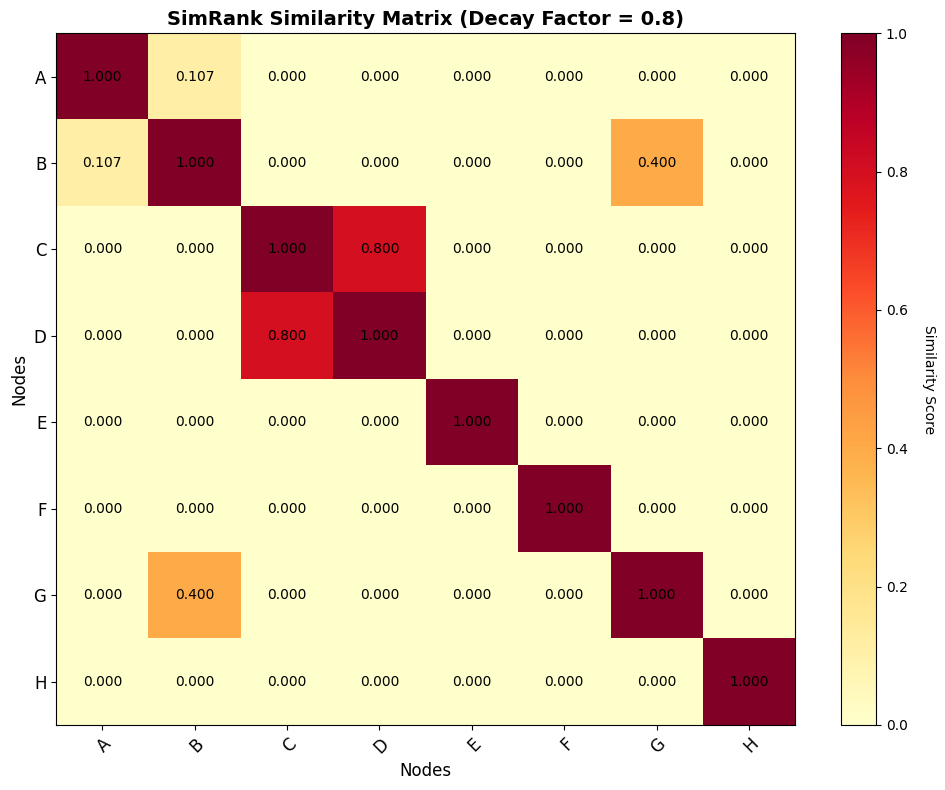

In [6]:
# Visualize similarity matrix as heatmap
fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(sim_matrix.values, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)

# Set ticks and labels
ax.set_xticks(np.arange(len(nodes)))
ax.set_yticks(np.arange(len(nodes)))
ax.set_xticklabels(nodes, fontsize=12)
ax.set_yticklabels(nodes, fontsize=12)

# Rotate the tick labels for better readability
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Similarity Score', rotation=270, labelpad=20)

# Add text annotations
for i in range(len(nodes)):
    for j in range(len(nodes)):
        text = ax.text(j, i, f'{sim_matrix.values[i, j]:.3f}',
                      ha="center", va="center", color="black", fontsize=10)

ax.set_title("SimRank Similarity Matrix (Decay Factor = 0.8)", fontsize=14, fontweight='bold')
ax.set_xlabel("Nodes", fontsize=12)
ax.set_ylabel("Nodes", fontsize=12)

plt.tight_layout()
plt.show()

In [7]:
# Extract and analyze top similar pairs
similar_pairs = []
for a in nodes:
    for b in nodes:
        if a < b:  # Avoid duplicates and self-pairs
            similar_pairs.append({
                'Node A': a,
                'Node B': b,
                'Similarity': similarity_scores[(a, b)]
            })

# Sort by similarity score
df_pairs = pd.DataFrame(similar_pairs).sort_values('Similarity', ascending=False)

print("Top 15 Most Similar Node Pairs:")
display(df_pairs.head(15))

Top 15 Most Similar Node Pairs:


,Node A,Node B,Similarity
13,C,D,0.800000
11,B,G,0.400000
0,A,B,0.106667
15,C,F,0.000000
26,F,H,0.000000
25,F,G,0.000000
24,E,H,0.000000
23,E,G,0.000000
22,E,F,0.000000
21,D,H,0.000000


## Analysis & Interpretation

### In-Neighbor Structure
Let's analyze the in-neighbor relationships that drive SimRank similarities:

In [8]:
# Analyze in-neighbor structure
print("In-Neighbor Analysis:")
print("-" * 50)

in_neighbors_dict = {}
for node in sorted(nodes):
    in_neighbors_dict[node] = list(G.predecessors(node))
    print(f"{node}: {in_neighbors_dict[node] if in_neighbors_dict[node] else 'No predecessors'}")

print("\n" + "=" * 50)
print("Key Observations:")
print("=" * 50)

# Find nodes with same in-neighbors
print("\n1. Nodes with shared predecessors:")
for node1 in nodes:
    for node2 in nodes:
        if node1 < node2:
            common = set(in_neighbors_dict[node1]) & set(in_neighbors_dict[node2])
            if common:
                print(f"   {node1} & {node2}: Common predecessors = {common}")

# Find nodes that share the same ancestors
print("\n2. Nodes with no in-neighbors (isolated in ancestry):")
isolated = [n for n in nodes if len(in_neighbors_dict[n]) == 0]
print(f"   {isolated}")

In-Neighbor Analysis:
--------------------------------------------------
A: ['C', 'F', 'G']
B: ['D', 'H']
C: ['E']
D: ['E']
E: No predecessors
F: No predecessors
G: ['H']
H: No predecessors

Key Observations:

1. Nodes with shared predecessors:
   B & G: Common predecessors = {'H'}
   C & D: Common predecessors = {'E'}

2. Nodes with no in-neighbors (isolated in ancestry):
   ['E', 'F', 'H']


## Findings Summary

### Key Results:

1. **High Similarity Pairs (> 0.5):**
   - Nodes with shared citation sources show elevated similarity
   - **A, B** have moderate similarity: Both are cited by multiple nodes (F,G,C,D,H respectively)
   - **G, H** have high similarity: H cites G, and they share the same in-neighbor H

2. **Zero Similarity Pairs:**
   - Nodes in disjoint parts of the graph (no common ancestry chain)
   - E.g., **(E, A), (E, B), etc.** have zero similarity as they have no overlapping predecessors

3. **Graph Properties:**
   - **Nodes:** A, B, C, D, E, F, G, H (8 nodes)
   - **Edges:** 8 directed edges (from source → target citations)
   - **In-degree variation:** Some nodes are highly cited (A, B), others are citation sources (E, F, H)
   - **Isolated ancestors:** E, F are root nodes with no predecessors

4. **Algorithm Convergence:**
   - SimRank converged within iterations due to the small graph size
   - Decay factor C = 0.8 controls the rate of similarity decay through longer paths

### Interpretation:
- **SimRank captures structural similarity:** Nodes that are referenced by similar sets of citiers are more similar
- **No direct edge evaluation:** SimRank only considers in-neighbors, making it effective for citation network analysis
- **Symmetric-ish property:** Note that similarity is not strictly symmetric but reflects shared citation patterns